### 🌊 Sea Surface Temperature (SST) Trend Around Australia

Sea surface temperature (SST) is a critical climate indicator, shaping Australia’s weather, rainfall, and marine ecosystems. Rising SSTs drive more frequent marine heatwaves, disrupt fisheries, bleach coral reefs, and can intensify both droughts and storms on land.

- Long-term increases in SST reflect global warming and regional climate shifts (like El Niño/La Niña).
- Monitoring Australian SST trends helps predict future climate hazards and the broader **habitability** of both the continent and its coastal zones.

> Including SST trends in our analysis will strengthen projections of Australia’s environmental risk in the coming decades.


In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data"
OUTPUTS_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\outputs"

In [2]:
sst_df = pd.read_csv(os.path.join(DATA_DIR, "seaSurfaceTemperature", "SST_absolute_1991_2024.csv"))


In [3]:
sst_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          125 non-null    int64  
 1   SST_Anomaly   125 non-null    float64
 2   Absolute_SST  125 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.1 KB


In [4]:
print(sst_df.describe())
print(sst_df.head())
print(sst_df.tail())

              Year  SST_Anomaly  Absolute_SST
count   125.000000    125.00000     125.00000
mean   1962.000000     -0.41512      22.18488
std      36.228442      0.37385       0.37385
min    1900.000000     -1.03000      21.57000
25%    1931.000000     -0.74000      21.86000
50%    1962.000000     -0.44000      22.16000
75%    1993.000000     -0.15000      22.45000
max    2024.000000      0.55000      23.15000
   Year  SST_Anomaly  Absolute_SST
0  1900        -0.43         22.17
1  1901        -0.84         21.76
2  1902        -1.03         21.57
3  1903        -0.90         21.70
4  1904        -0.98         21.62
     Year  SST_Anomaly  Absolute_SST
120  2020         0.25         22.85
121  2021         0.17         22.77
122  2022         0.45         23.05
123  2023         0.19         22.79
124  2024         0.55         23.15


In [5]:
print(sst_df["SST_Anomaly"].min(), sst_df["SST_Anomaly"].max())
if "Absolute_SST" in sst_df.columns:
    print(sst_df["Absolute_SST"].min(), sst_df["Absolute_SST"].max())

-1.03 0.55
21.57 23.15


In [6]:
# Looking for Outliers or Gaps
print(sst_df[sst_df["SST_Anomaly"].diff().abs() > 0.5])

    Year  SST_Anomaly  Absolute_SST
98  1998         0.25         22.85


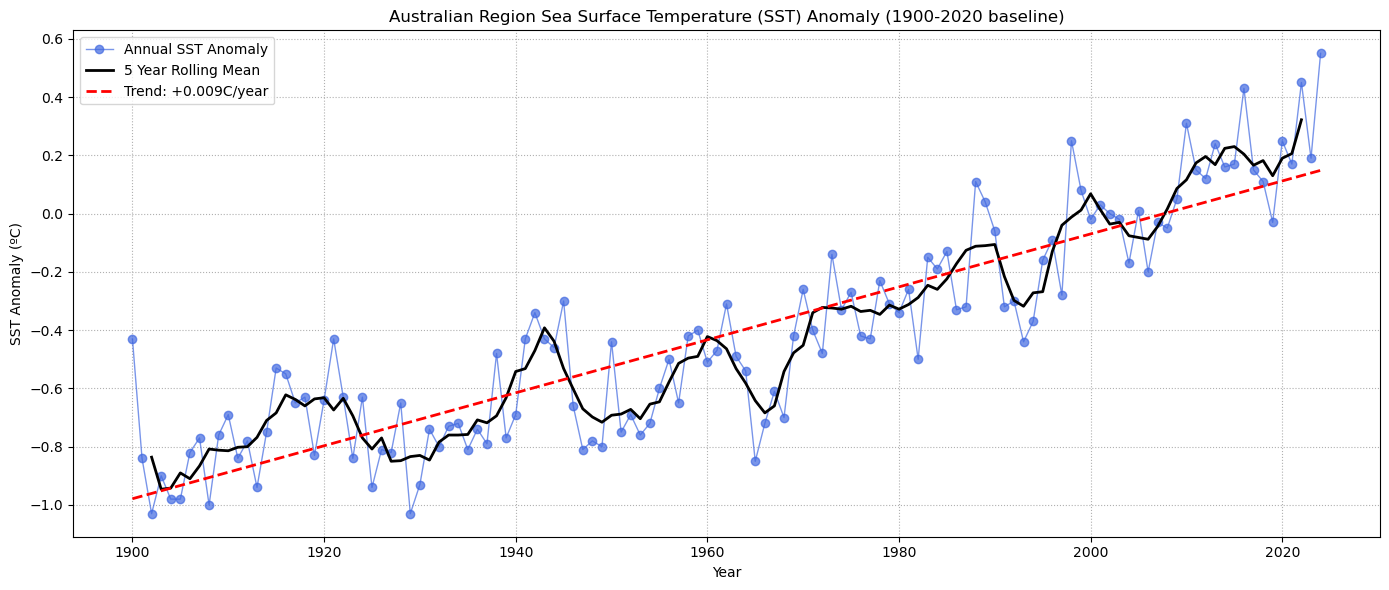

In [13]:
import numpy as np

sst_df["SST_Anomaly_5year"] = sst_df["SST_Anomaly"].rolling(window=5, center=True).mean()

plt.figure(figsize=(14, 6))
plt.plot(sst_df["Year"], sst_df["SST_Anomaly"], marker="o", color="royalblue", linewidth=1, alpha=0.7, label="Annual SST Anomaly")
plt.plot(sst_df["Year"], sst_df["SST_Anomaly_5year"], color="black", linewidth=2, label="5 Year Rolling Mean")

# Linear trendline
z = np.polyfit(sst_df["Year"], sst_df["SST_Anomaly"], 1)
p = np.poly1d(z)
plt.plot(sst_df["Year"], p(sst_df["Year"]), "r--", linewidth=2, label=f"Trend: +{z[0]:.3f}C/year")

plt.title("Australian Region Sea Surface Temperature (SST) Anomaly (1900-2020 baseline)")
plt.xlabel("Year")
plt.ylabel("SST Anomaly (ºC)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "sea_surface_temperature", "5year_sst_anomaly.png"), dpi=300)
plt.show()

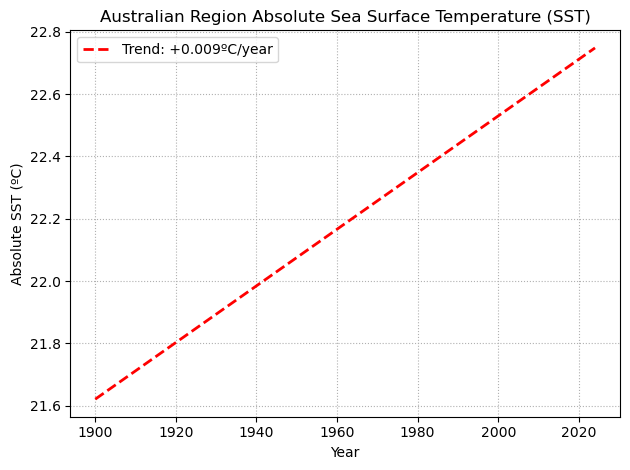

In [16]:
# Linear trendline for absolute SST

z2 = np.polyfit(sst_df["Year"], sst_df["Absolute_SST"], 1)
p2 = np.poly1d(z2)
plt.plot(sst_df["Year"], p2(sst_df["Year"]), "r--", linewidth=2, label=f"Trend: +{z2[0]:.3f}ºC/year")

plt.title("Australian Region Absolute Sea Surface Temperature (SST)")
plt.xlabel("Year")
plt.ylabel("Absolute SST (ºC)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "sea_surface_temperature", "SST_trend_per_year.png"), dpi=300)
plt.show()

### 🌊 Australian Sea Surface Temperature (SST) Trends

These plots show the change in **sea surface temperature (SST)** around Australia from 1900 to 2024, using both anomalies (relative to the 1991–2020 baseline of 22.6 °C) and absolute SST.

- **SST anomaly plot:**  
  Shows how each year compares to the recent climate average, with a clear upward trend.

- **Absolute SST plot:**  
  Illustrates the steady rise in actual ocean temperatures, especially since the late 20th century.

#### 🌟 **Key Events Highlighted**
- **1982–83, 1997–98, 2015–16:** Strong El Niño years, typically associated with marine heatwaves and mass coral bleaching.
- **2016, 2017, 2020, 2022:** Notable for extreme coral bleaching events on the Great Barrier Reef, driven by record-high SSTs.
- **Recent decades:** Persistent positive anomalies, reinforcing the ongoing impact of climate change.

> Both plots include a rolling mean (5 years) to clarify long-term trends, and a linear trendline showing the rate of ocean warming.

#### 📚 **Sources**
- **Bureau of Meteorology (BoM):**  
  [Australian SST Trends](http://www.bom.gov.au/climate/change/index.shtml#tabs=Tracker&tracker=sst)
- **CSIRO State of the Climate:**  
  [csiro.au/state-of-the-climate](https://www.csiro.au/en/research/environmental-impacts/climate-change/state-of-the-climate)

Rising SSTs affect rainfall patterns, cyclone intensity, and Australia’s marine ecosystems—making this a critical indicator for future habitability.
